In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!find /content/drive/MyDrive -name "datos.csv"

/content/drive/MyDrive/PROGRAMACION COMUNICACIONES DIGITALES /CONCEPTOS DE EXPLORACION A D/datos.csv


Periodo detectado: 10004 µs (de 6010 a 16014 µs)
Muestras dentro del periodo (9): [ 7014  8011  9009 10013 11009 12013 13010 14014 15010]


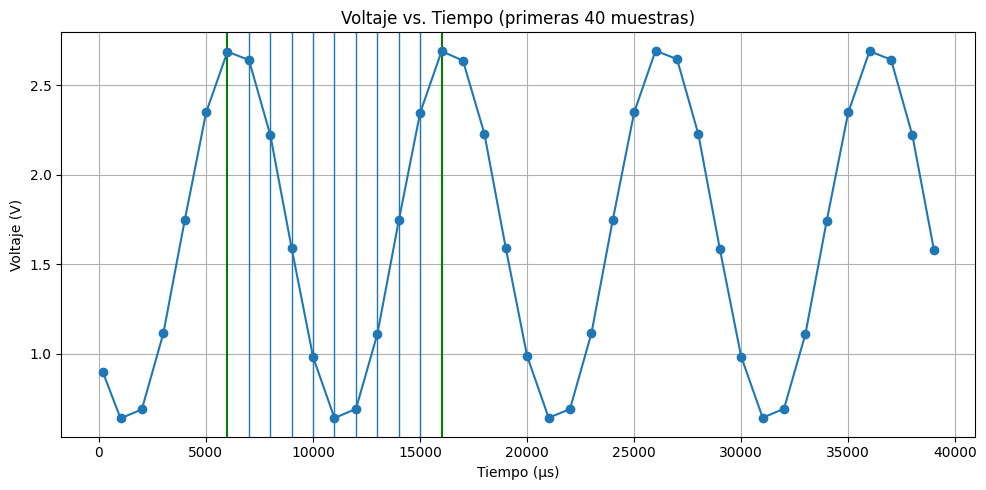

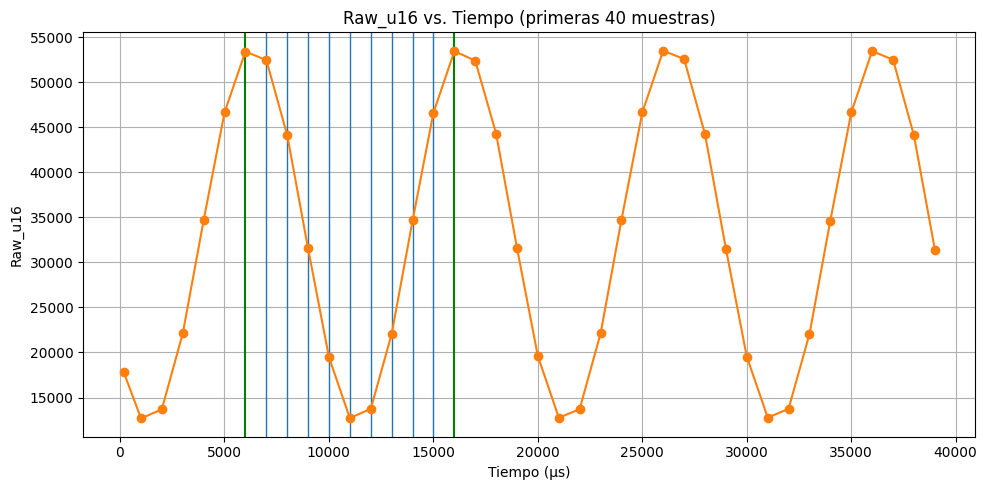

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Ruta del archivo
ruta = "/content/drive/MyDrive/PROGRAMACION COMUNICACIONES DIGITALES /CONCEPTOS DE EXPLORACION A D/datos.csv"

# Leer el CSV (separador ';' y decimal ',')
df = pd.read_csv(ruta, sep=';', decimal=',')

# Tomar solo las primeras 40 muestras para graficar
df_40 = df.head(40)
t40 = df_40['Time_us'].values

# --- Detección automática de un periodo usando los picos de Raw_u16 (con TODO el dataset) ---
t_full = df['Time_us'].values
y_full = df['Raw_u16'].values
peaks, _ = find_peaks(y_full, distance=5, prominence=(y_full.max() - y_full.min()) * 0.3)

t_ini = t_full[peaks[0]]   # inicio del periodo (primer pico)
t_fin = t_full[peaks[1]]   # fin del periodo (segundo pico)
periodo = t_fin - t_ini
print(f"Periodo detectado: {periodo} µs (de {t_ini} a {t_fin} µs)")

# Instantes de muestra REALES que caen dentro del periodo (no puntos sintéticos)
mask_periodo = (t_full > t_ini) & (t_full < t_fin)
puntos_muestreo = t_full[mask_periodo]
print(f"Muestras dentro del periodo ({len(puntos_muestreo)}):", puntos_muestreo)

def marcar_periodo(ax):
    ax.axvline(t_ini, color='green', linewidth=1.5)
    ax.axvline(t_fin, color='green', linewidth=1.5)
    for p in puntos_muestreo:
        ax.axvline(p, color='tab:blue', linewidth=1)

# --- Gráfica 1: Voltaje (V) vs. Tiempo (µs) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t40, df_40['Voltage_V'], marker='o', color='tab:blue', zorder=3)
marcar_periodo(ax)
ax.set_title('Voltaje vs. Tiempo (primeras 40 muestras)')
ax.set_xlabel('Tiempo (µs)')
ax.set_ylabel('Voltaje (V)')
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Gráfica 2: raw_u16 vs. Tiempo (µs) ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t40, df_40['Raw_u16'], marker='o', color='tab:orange', zorder=3)
marcar_periodo(ax)
ax.set_title('Raw_u16 vs. Tiempo (primeras 40 muestras)')
ax.set_xlabel('Tiempo (µs)')
ax.set_ylabel('Raw_u16')
ax.grid(True)
plt.tight_layout()
plt.show()